# Student Performance Prediction

## Import Libraries

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [20]:
data = pd.read_excel("../datasets/regression/Student_Performance.xlsx")
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


## Data Overview

In [21]:
excel_file = pd.ExcelFile('../datasets/regression/Student_Performance.xlsx')

excel_file.sheet_names

['Student_Performance']

In [22]:
data.shape

(10000, 6)

In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     10000 non-null  int64
 1   Previous Scores                   10000 non-null  int64
 2   Extracurricular Activities        10000 non-null  str  
 3   Sleep Hours                       10000 non-null  int64
 4   Sample Question Papers Practiced  10000 non-null  int64
 5   Performance Index                 10000 non-null  int64
dtypes: int64(5), str(1)
memory usage: 468.9 KB


In [24]:
print("Missing values:")
print(data.isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Missing values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Duplicate rows: 127


## Encode Categories

In [25]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['Extracurricular Activities'] = encoder.fit_transform(data['Extracurricular Activities'])


In [26]:
print('Classes:', encoder.classes_)
data[['Extracurricular Activities']].head()

Classes: ['No' 'Yes']


,Extracurricular Activities
0,1
1,0
2,1
3,1
4,0


## Select Features

In [27]:
X = data.drop(['Performance Index'],axis =1)
X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


In [28]:
y = data['Performance Index']
y.head()

0    91
1    65
2    45
3    36
4    66
Name: Performance Index, dtype: int64

## Split Dataset

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


## Train Model

In [30]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [31]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.85,1.02,0.61,0.48,0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Extracurricular Activities', 'Sleep Hours','Sample Question Papers Practiced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.92
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


## Make Predictions

In [32]:
y_pred = model.predict(X_test)
y_pred[:5]

array([54.71185392, 22.61551294, 47.90314471, 31.28976748, 43.00457042])

## Model Evaluation

In [33]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R² Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

R² Score: 0.9889832909573145
Mean Absolute Error: 1.6111213463123044
Root Mean Squared Error: 2.0205515085050054


## Compare Results

In [34]:
comparison = pd.DataFrame({
    'Actual Performance': y_test,
    'Predicted Performance': y_pred
})
comparison.head()

,Actual Performance,Predicted Performance
6252,51,54.711854
4684,20,22.615513
1731,46,47.903145
4742,28,31.289767
4521,41,43.004570


## Visualize Results

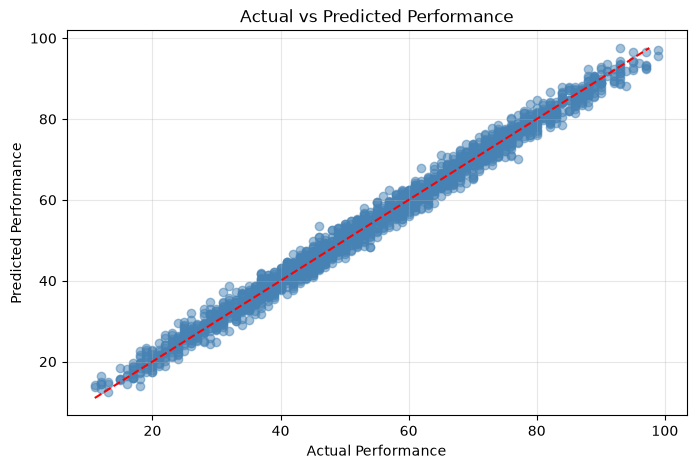

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')

minimum = min(y_test.min(),y_pred.min())
maximum = min(y_test.max(),y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color='red',
    linestyle= '--'

)

plt.xlabel('Actual Performance')
plt.ylabel('Predicted Performance')
plt.title('Actual vs Predicted Performance')
plt.grid(alpha = 0.3)
plt.show()
